In [ ]:
import kagglehub

In [ ]:
local_dataset_path = kagglehub.dataset_download('irkaal/foodcom-recipes-and-reviews')

Using Colab cache for faster access to the 'foodcom-recipes-and-reviews' dataset.


In [ ]:
import pandas as pd
import matplotlib.pyplot as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import os
full_reviews_path = os.path.join(local_dataset_path, 'reviews.csv')
reviews = pd.read_csv(full_reviews_path)

In [ ]:
!pip install gdown

# ID del archivo de Google Drive
file_id = '1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG'
output_filename = 'recipes_final_consolidado.csv'

# Descargar el archivo usando gdown
!gdown --id {file_id} -O {output_filename}

# Cargar el archivo CSV con pandas
recipes = pd.read_csv(output_filename)
recipes['ExtractedServingSize'] = recipes['ExtractedServingSize'].str.extract(r'\((.*?)\)').astype(float)

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG
From (redirected): https://drive.google.com/uc?id=1Rl8XowC9N6cxrdiPvH4wToFUvZrrBqRG&confirm=t&uuid=893d3d79-e54a-48db-9932-8eb19e4441d4
To: /content/recipes_final_consolidado.csv
100% 713M/713M [00:08<00:00, 82.9MB/s]


In [ ]:
recipes.head()

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions,ExtractedServingSize,ExtractedServings,ExtractedServings_clean,ConsolidatedServings
0,38,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09T21:46:00Z,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,3.6,30.2,3.2,4.0,NaN,"c(""Toss 2 cups berries with sugar."", ""Let stan...",225.0,4,4,4
1,39,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29T13:12:00Z,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",...,9.0,20.4,63.4,6.0,NaN,"c(""Soak saffron in warm milk for 5 minutes and...",799.0,6,6,6
2,40,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05T19:52:00Z,This is from one of my first Good House Keepi...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,0.4,77.2,0.3,4.0,NaN,"c(""Into a 1 quart Jar with tight fitting lid, ...",212.0,4,4,4
3,41,Carina's Tofu-Vegetable Kebabs,1586,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03T14:54:00Z,This dish is best prepared a day in advance to...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,17.3,32.1,29.3,2.0,4 kebabs,"c(""Drain the tofu, carefully squeezing out exc...",932.0,2,2,2
4,42,Cabbage Soup,1538,Duckie067,PT30M,PT20M,PT50M,1999-09-19T06:19:00Z,Make and share this Cabbage Soup recipe from F...,"""https://img.sndimg.com/food/image/upload/w_55...",...,4.8,17.7,4.3,4.0,NaN,"c(""Mix everything together and bring to a boil...",493.0,4,4,4


In [ ]:
recipes.describe()

,RecipeId,AuthorId,AggregatedRating,ReviewCount,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,ExtractedServingSize,ExtractedServings,ExtractedServings_clean,ConsolidatedServings
count,522359.000000,5.223590e+05,269236.000000,274966.000000,522359.000000,522359.000000,522359.000000,522359.000000,5.223590e+05,522359.000000,522359.000000,522359.000000,522359.000000,339518.000000,5.223590e+05,522359.000000,522359.000000,522359.000000
mean,271779.934955,4.571464e+07,4.632005,5.228086,484.455835,24.615802,9.559874,86.489635,7.672775e+02,49.091347,3.843317,21.880696,17.469768,8.606021,3.791469e+02,7.000892,7.000892,7.000892
std,155483.474392,2.929395e+08,0.641940,20.383440,1397.316967,111.501885,46.629446,302.029002,4.204148e+03,180.848298,8.604247,142.641106,40.133697,114.334412,2.641961e+03,92.241139,92.241139,92.241139
min,38.000000,2.700000e+01,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000,-4.750000e+02,1.000000,1.000000,1.000000
25%,137175.500000,6.947400e+04,4.500000,1.000000,174.100000,5.600000,1.500000,3.800000,1.233000e+02,12.800000,0.800000,2.500000,3.500000,4.000000,1.200000e+02,3.000000,3.000000,3.000000
50%,271707.000000,2.387790e+05,5.000000,2.000000,317.100000,13.800000,4.700000,42.600000,3.533000e+02,28.200000,2.200000,6.400000,9.100000,6.000000,2.180000e+02,4.000000,4.000000,4.000000
75%,406076.500000,5.658280e+05,5.000000,4.000000,529.100000,27.400000,10.800000,107.900000,7.922000e+02,51.100000,4.600000,17.900000,25.000000,8.000000,3.810000e+02,8.000000,8.000000,8.000000
max,541383.000000,2.002886e+09,5.000000,3063.000000,612854.600000,64368.100000,26740.600000,130456.400000,1.246921e+06,108294.600000,3012.000000,90682.300000,18396.200000,32767.000000,1.595816e+06,32767.000000,32767.000000,32767.000000


In [ ]:
# Filtrar la receta con ExtractedServingSize igual a -475.0
receta_anomala = recipes[recipes['ExtractedServingSize'] == -475.0]
display(receta_anomala)

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions,ExtractedServingSize,ExtractedServings,ExtractedServings_clean,ConsolidatedServings
16628,19962,Rainforest Cafe Rasta Pasta for Two or Three,10404,Diana Adcock,PT15M,PT5M,PT20M,2002-02-18T09:24:00Z,Make and share this Rainforest Cafe Rasta Past...,"""https://img.sndimg.com/food/image/upload/w_55...",...,7.2,4.8,19.7,2.0,NaN,"c(""Cook pasta according to package directions....",-475.0,2,2,2


In [ ]:
# Buscar todas las recetas con ExtractedServingSize negativo
recetas_negativas = recipes[recipes['ExtractedServingSize'] < 0]
display(recetas_negativas)
print(f"Total de recetas con ExtractedServingSize negativo: {len(recetas_negativas)}")

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions,ExtractedServingSize,ExtractedServings,ExtractedServings_clean,ConsolidatedServings
16628,19962,Rainforest Cafe Rasta Pasta for Two or Three,10404,Diana Adcock,PT15M,PT5M,PT20M,2002-02-18T09:24:00Z,Make and share this Rainforest Cafe Rasta Past...,"""https://img.sndimg.com/food/image/upload/w_55...",...,7.2,4.8,19.7,2.0,NaN,"c(""Cook pasta according to package directions....",-475.0,2,2,2


Total de recetas con ExtractedServingSize negativo: 1


In [ ]:
reviews.head()

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25T21:44:00Z,2000-01-25T21:44:00Z
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25T09:00:00Z,2000-02-25T09:00:00Z
3,13,7435,1773,Malarkey Test,5,easily the best i have ever had. juicy flavor...,2000-03-13T21:15:00Z,2000-03-13T21:15:00Z
4,14,44,2085,Tony Small,5,An excellent dish.,2000-03-28T12:51:00Z,2000-03-28T12:51:00Z


In [ ]:
#Número de interacciones de usuarios con recetas
reviews.groupby('AuthorId').count().sort_values(by='Review', ascending=False)

,ReviewId,RecipeId,AuthorName,Rating,Review,DateSubmitted,DateModified
AuthorId,,,,,,,
424680,8842,8842,8842,8842,8842,8842,8842
37449,6605,6605,6605,6605,6605,6605,6605
383346,5438,5438,5438,5438,5438,5438,5438
128473,4693,4693,4693,4693,4693,4693,4693
169430,4586,4586,4586,4586,4586,4586,4586
...,...,...,...,...,...,...,...
2689825,1,1,1,1,0,1,1
2407649,1,1,1,1,0,1,1
2270186,1,1,1,1,0,1,1


In [ ]:
reviews.Rating.value_counts()

,count
Rating,
5,1012082
4,229217
0,76248
3,50279
2,17597
1,16559


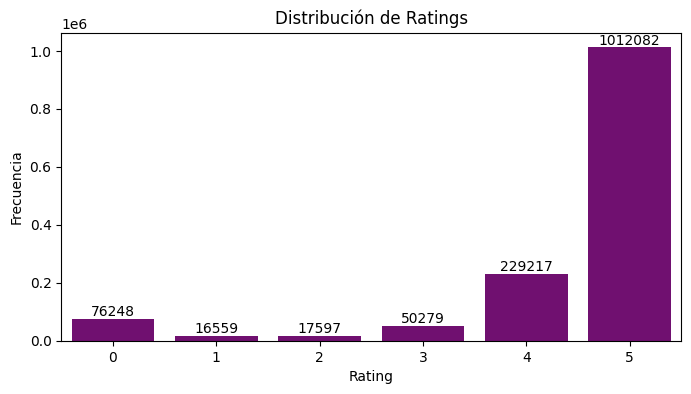

In [ ]:
#Gráfico de barras con distribución de ratings
plt.figure(figsize=(8, 4))
sns.countplot(x='Rating', data=reviews, color='purple')
plt.title('Distribución de Ratings')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')

for i in range(6):
    plt.text(i, reviews.Rating.value_counts()[i], reviews.Rating.value_counts()[i], ha='center', va='bottom')

plt.show()

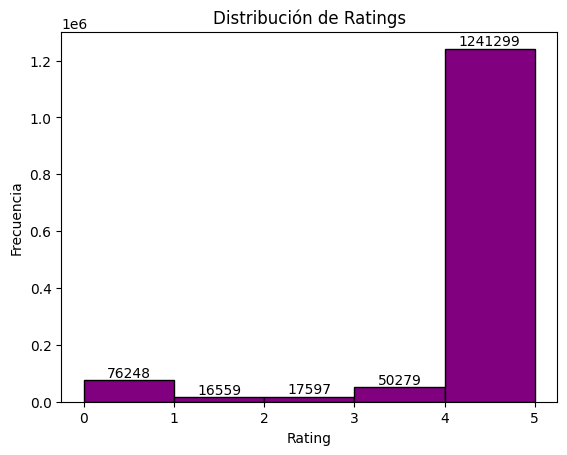

In [ ]:
#Distribución de ratings - histograma
counts, bins, patches = plt.hist(reviews.Rating, bins=5, color='purple', edgecolor='black')
plt.title('Distribución de Ratings')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')
plt.ylim(0, 1300000)

for i in range(5):
    if counts[i] > 0:
        plt.text(bins[i] + (bins[i+1] - bins[i])/2,
                 counts[i] + 100,
                 int(counts[i]),
                 ha='center',
                 va='bottom')
plt.show()

In [ ]:
reviews.groupby('AuthorId')['Rating'].count().sort_values(ascending=False)

,Rating
AuthorId,
424680,8842
37449,6605
383346,5438
128473,4693
169430,4586
...,...
1505873,1
1505896,1
1505897,1


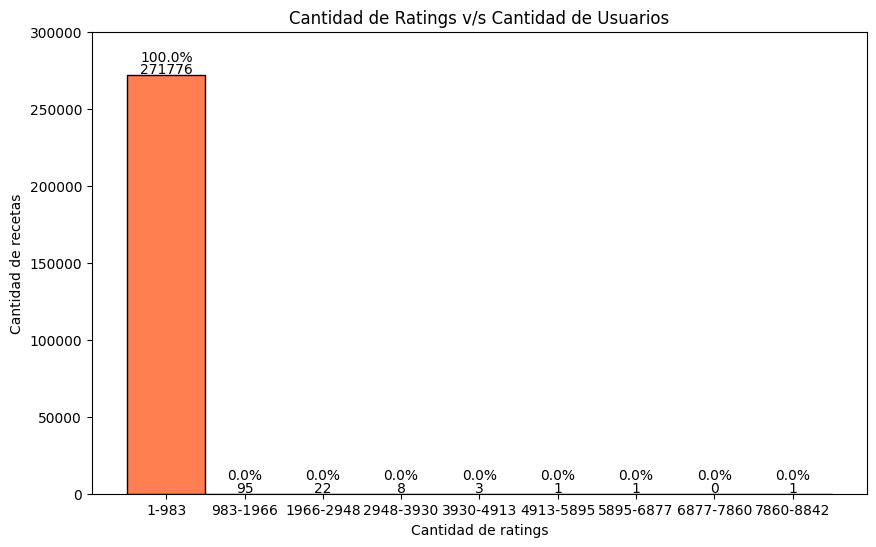

In [ ]:
user_interactions_count = reviews.groupby('AuthorId')['Rating'].count()
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(user_interactions_count, bins = 9, color='coral', edgecolor='black')
plt.title('Cantidad de Ratings v/s Cantidad de Usuarios')
plt.xlabel('Cantidad de ratings')
plt.ylabel('Cantidad de recetas')
plt.ylim(0, 300000)
for i in range(len(counts)):
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, counts[i] + 1000, int(counts[i]), ha='center')
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, counts[i] + 9000, f'{(counts[i]/len(user_interactions_count))*100:.1f}%', ha='center')

bin_labels = [f'{bins[i]:.0f}-{bins[i+1]:.0f}' for i in range(len(bins)-1)]
plt.xticks([(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)], bin_labels)
plt.show()

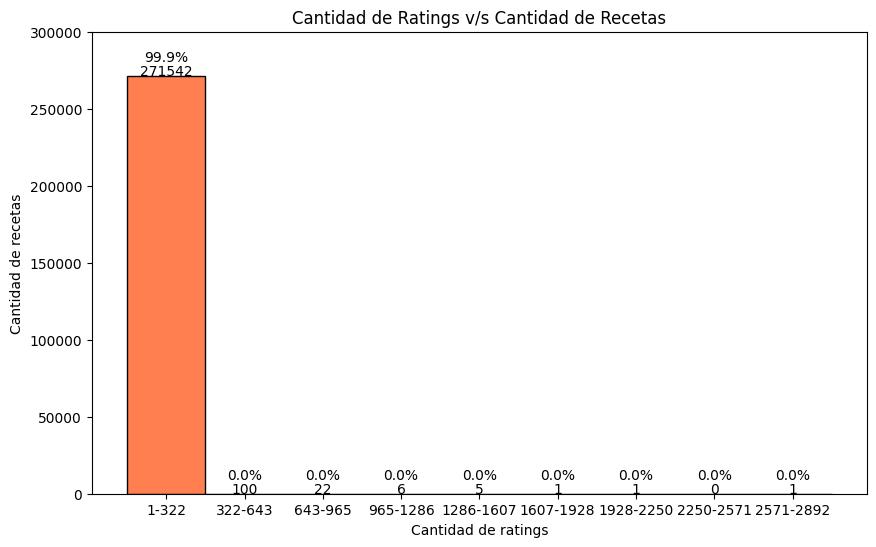

In [ ]:
user_interactions_count = reviews.groupby('RecipeId')['Rating'].count()
plt.figure(figsize=(10, 6))
counts, bins, patches = plt.hist(user_interactions_count, bins = 9, color='coral', edgecolor='black')
plt.title('Cantidad de Ratings v/s Cantidad de Recetas')
plt.xlabel('Cantidad de ratings')
plt.ylabel('Cantidad de recetas')
plt.ylim(0, 300000)
for i in range(len(counts)):
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, counts[i] + 10, int(counts[i]), ha='center')
    plt.text(bins[i] + (bins[i+1] - bins[i])/2, counts[i] + 9000, f'{(counts[i]/len(user_interactions_count))*100:.1f}%', ha='center')

bin_labels = [f'{bins[i]:.0f}-{bins[i+1]:.0f}' for i in range(len(bins)-1)]
plt.xticks([(bins[i] + bins[i+1])/2 for i in range(len(bins)-1)], bin_labels)
plt.show()

In [ ]:
# Usuarios que han hecho 1 review o menos
review_counts = reviews['AuthorId'].value_counts()
little_review_users = review_counts[review_counts == 1]
len(little_review_users)

199808

In [ ]:
little_review_users

,count
AuthorId,
2001112619,1
2001061466,1
2000524084,1
2001068797,1
2001061706,1
...,...
1704446,1
1417548,1
1704190,1


In [ ]:
total_users = reviews['AuthorId'].nunique()
print("Proporción de usuarios que han hecho solo un 1 review en el dataset:", round(len(little_review_users) / total_users * 100, 2), "%")

Proporción de usuarios que han hecho solo un 1 review en el dataset: 73.48 %


In [ ]:
# Recetas que tienen 1 review
recipe_counts = reviews['RecipeId'].value_counts()
little_review_recipes = recipe_counts[recipe_counts == 1]
len(little_review_recipes)

106541

In [ ]:
total_recipes = reviews['RecipeId'].nunique()
print("Proporción de recetas que tienen solo 1 review en el dataset:", round(len(little_review_recipes) / total_recipes * 100, 2), "%")

Proporción de recetas que tienen solo 1 review en el dataset: 39.22 %


In [ ]:
little_review_recipes

,count
RecipeId,
230339,1
148,1
4053,1
535302,1
508069,1
...,...
487383,1
530961,1
469154,1


In [ ]:
reviews[reviews['RecipeId'] == 540899]

,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
1398924,2087065,540899,2002811014,Rick J.,5,We had these for breakfast this morning. They ...,2020-09-03T17:55:43Z,2020-09-03T17:55:43Z


In [ ]:
recipe_name = recipes[recipes['RecipeId'] == 363893]['Name'].iloc[0]
print(f"The name of the recipe with ID 363893 is: {recipe_name}")

The name of the recipe with ID 363893 is: Cowpoke Pintos


In [ ]:
# Filtrar y mostrar todas las columnas para la receta 363893
recipe_details = recipes[recipes['RecipeId'] == 363893]
recipe_details

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions,ExtractedServingSize,ExtractedServings,ExtractedServings_clean,ConsolidatedServings
350896,363893,Cowpoke Pintos,808027,Epi Curious,PT3H20M,PT30M,PT3H50M,2009-04-01T03:45:00Z,These are some of the best baked beans (pintos...,character(0),...,14.7,11.1,19.3,NaN,6-8,"c(""Soak the beans overnight in water to cover....",461.0,6,6,6


In [ ]:
def get_stats(recipes, reviews):
  num_users = reviews['AuthorId'].nunique()
  num_items = recipes['RecipeId'].nunique()
  total_ratings = len(reviews)
  avg_ratings_per_user = total_ratings / num_users
  avg_ratings_per_item = total_ratings / num_items
  avg_rating = reviews['Rating'].mean()
  mode_rating = reviews['Rating'].mode()[0]
  std_rating = reviews['Rating'].std()
  highest_ratings_user = reviews.groupby('AuthorId')['Rating'].count().max()
  highest_ratings_item = reviews.groupby('RecipeId')['Rating'].count().max()
  density = (total_ratings / (num_users * num_items)) * 100
  return [
      num_users,
      num_items,
      total_ratings,
      round(avg_ratings_per_user, 2),
      round(avg_ratings_per_item, 2),
      round(avg_rating, 2),
      mode_rating,
      round(std_rating, 2),
      highest_ratings_user,
      highest_ratings_item,
      f"{density:.2f} %"
  ]

stats_names = [
    "Cantidad de usuarios",
    "Cantidad de recetas",
    "Total de ratings",
    "Número promedio de ratings por usuario",
    "Número promedio de ratings por recetas",
    "Rating promedio",
    "Rating Moda",
    "Desviación estándar de Rating",
    "Cantidad más alta de ratings de un usuario",
    "Cantidad más alta de ratings de una receta",
    "Densidad (%)"
]

todo_stats = get_stats(recipes, reviews)
#val_stats = get_stats(val_file)

summary_df = pd.DataFrame({
    'Estadísticas': stats_names,
    'Todo': todo_stats,
})

display(summary_df)

,Estadísticas,Todo
0,Cantidad de usuarios,271907
1,Cantidad de recetas,522359
2,Total de ratings,1401982
3,Número promedio de ratings por usuario,5.16
4,Número promedio de ratings por recetas,2.68
5,Rating promedio,4.41
6,Rating Moda,5
7,Desviación estándar de Rating,1.27
8,Cantidad más alta de ratings de un usuario,8842
9,Cantidad más alta de ratings de una receta,2892


In [ ]:
# Estadísticas tras recorte/filtración

reviews_filtrado = reviews[~reviews['AuthorId'].isin(little_review_users.index)]
# reviews_filtrado = reviews_filtrado[~reviews_filtrado['RecipeId'].isin(little_review_recipes.index)]
recipes_filtrado = recipes[recipes['RecipeId'].isin(reviews_filtrado['RecipeId'].unique())]

filtrado_stats = get_stats(recipes_filtrado, reviews_filtrado)

summary_df = pd.DataFrame({
    'Estadísticas': stats_names,
    'Todo': todo_stats,
    'Filtrado': filtrado_stats,
})

display(summary_df)



,Estadísticas,Todo,Filtrado
0,Cantidad de usuarios,271907,72099
1,Cantidad de recetas,522359,258314
2,Total de ratings,1401982,1202174
3,Número promedio de ratings por usuario,5.16,16.67
4,Número promedio de ratings por recetas,2.68,4.65
5,Rating promedio,4.41,4.52
6,Rating Moda,5,5
7,Desviación estándar de Rating,1.27,1.07
8,Cantidad más alta de ratings de un usuario,8842,8842
9,Cantidad más alta de ratings de una receta,2892,2359


Mi teoría es que, con la limpieza de datos, debería demorarse menos en entrenar y obtener resultados similares, ya que los usuarios con solo una interacción no entregan suficiente información para recomendar recetas de forma correcta.

In [ ]:
from sklearn.model_selection import train_test_split
import time

K = 1000

train_full, test_full = train_test_split(reviews, test_size=0.2, random_state=42)
train_filtrado, test_filtrado = train_test_split(reviews_filtrado, test_size=0.2, random_state=42)

In [ ]:
start = time.time()
popular_full = train_full.groupby('RecipeId')['Rating'].count().sort_values(ascending=False)
tiempo_full = time.time() - start

start = time.time()
popular_filtrado = train_filtrado.groupby('RecipeId')['Rating'].count().sort_values(ascending=False)
tiempo_filtrado = time.time() - start

print(f"Tiempo entrenamiento - Dataset completo: {tiempo_full:.4f} segundos")
print(f"Tiempo entrenamiento - Dataset filtrado: {tiempo_filtrado:.4f} segundos")
print(f"Reducción de tiempo: {((tiempo_full - tiempo_filtrado) / tiempo_full * 100):.1f}%")

Tiempo entrenamiento - Dataset completo: 0.5032 segundos
Tiempo entrenamiento - Dataset filtrado: 0.2592 segundos
Reducción de tiempo: 48.5%


In [ ]:
# Metricas
def ndcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        idcg = sum(1 / np.log2(i + 2) for i in range(min(int(r.sum()), k)))
        dcg = sum(r[i] / np.log2(i + 2) for i in range(len(r)))
        return dcg / idcg if idcg > 0 else 0.
    return 0.

def evaluate_most_popular(popular_recipes, test_df, k=10):
    top_k_list = list(popular_recipes.head(k).index)
    top_k_set = set(top_k_list)

    test_df = test_df.copy()
    test_df['hit'] = test_df['RecipeId'].isin(top_k_set)

    user_stats = test_df.groupby('AuthorId').agg(
        hits=('hit', 'sum'),
        total=('RecipeId', 'count')
    )

    user_test_items = test_df.groupby('AuthorId')['RecipeId'].apply(set)
    ndcg_total = sum(
        ndcg_at_k([1 if item in items else 0 for item in top_k_list], k)
        for items in user_test_items
    )

    precision = round((user_stats['hits'] / k).mean(), 4)
    recall = round((user_stats['hits'] / user_stats['total']).mean(), 4)
    ndcg = round(ndcg_total / len(user_stats), 4)
    return precision, recall, ndcg

prec_full, rec_full, ndcg_full = evaluate_most_popular(popular_full, test_full, K)
prec_filtrado, rec_filtrado, ndcg_filtrado = evaluate_most_popular(popular_filtrado, test_filtrado, K)

results_df = pd.DataFrame({
    'Métrica': [f'Precision@{K}', f'Recall@{K}', f'nDCG@{K}'],
    'completo': [prec_full, rec_full, ndcg_full],
    'filtrado': [prec_filtrado, rec_filtrado, ndcg_filtrado]
})

display(results_df)

,Métrica,completo,filtrado
0,Precision@1000,0.0005,0.0008
1,Recall@1000,0.2171,0.2126
2,nDCG@1000,0.0588,0.0757


### Análisis sobre los "Sellos" (Nutricionales)
Actualmente estamos usando datos como `Calories`, `SugarContent`, `SodiumContent`, y `SaturatedFatContent`. Para aplicar la lógica de los "sellos" (como la ley de etiquetado en Chile), se puede crear una función que asigne un sello negro si los valores superan cierto umbral por cada 100g. Esta información puede ser utilizada en el futuro como un filtro post-recomendación, o para penalizar recetas con muchos sellos en la recomendación de usuarios que prefieren comida saludable.

### Modelo Aleatorio (Random Baseline)
A continuación, implementamos un modelo de recomendación aleatorio puro. Esto nos sirve como la línea base más simple posible para asegurar que nuestros modelos de popularidad y Content-Based realmente están aprendiendo algo útil.

In [ ]:
import random

def ndcg_at_k(r, k):
    r = np.asarray(r)[:k]
    if r.size:
        idcg = sum(1 / np.log2(i + 2) for i in range(min(int(r.sum()), k)))
        dcg = sum(r[i] / np.log2(i + 2) for i in range(len(r)))
        return dcg / idcg if idcg > 0 else 0.
    return 0.

def evaluate_random(recipes_df, test_df, k=1000):
    # Obtener todas las recetas disponibles
    all_recipe_ids = recipes_df['RecipeId'].unique().tolist()

    # Agrupar las interacciones de prueba por usuario
    user_stats = test_df.groupby('AuthorId').agg(
        total=('RecipeId', 'count')
    )

    hits_list = []
    ndcg_list = []
    # Para un dataset muy grande, esto puede demorar un poco, pero es necesario para la métrica exacta
    for user_id in user_stats.index:
        user_test_items = test_df[test_df['AuthorId'] == user_id]['RecipeId'].tolist()
        # Recomendar k items aleatorios
        recs = random.sample(all_recipe_ids, min(k, len(all_recipe_ids)))
        # Calcular hits
        hits = len(set(recs).intersection(set(user_test_items)))
        hits_list.append(hits)
        # Calcular nDCG
        rel_vector = [1 if item in set(user_test_items) else 0 for item in recs]
        ndcg_list.append(ndcg_at_k(rel_vector, k))

    user_stats['hits'] = hits_list

    precision = round((user_stats['hits'] / k).mean(), 4)
    recall = round((user_stats['hits'] / user_stats['total']).mean(), 4)
    ndcg = round(np.mean(ndcg_list), 4)
    return precision, recall, ndcg

start = time.time()
prec_rand_full, rec_rand_full, ndcg_rand_full = evaluate_random(recipes, test_full, K)
tiempo_rand_full = time.time() - start

start = time.time()
prec_rand_filt, rec_rand_filt, ndcg_rand_filt = evaluate_random(recipes_filtrado, test_filtrado, K)
tiempo_rand_filt = time.time() - start

results_random_df = pd.DataFrame({
    'Métrica': [f'Precision@{K} (Random)', f'Recall@{K} (Random)', f'nDCG@{K} (Random)'],
    'completo': [prec_rand_full, rec_rand_full, ndcg_rand_full],
    'filtrado': [prec_rand_filt, rec_rand_filt, ndcg_rand_filt]
})

print(f"Tiempo modelo aleatorio completo: {tiempo_rand_full:.2f} s")
print(f"Tiempo modelo aleatorio filtrado: {tiempo_rand_filt:.2f} s")
display(results_random_df)


Tiempo modelo aleatorio completo: 306.44 s
Tiempo modelo aleatorio filtrado: 158.90 s


,Métrica,completo,filtrado
0,Precision@1000 (Random),0.0000,0.0000
1,Recall@1000 (Random),0.0017,0.0037
2,nDCG@1000 (Random),0.0007,0.0024


### Modelo de Aprendizaje Reforzado (Bandidos Multibrazo con Mabwiser)
Implementaremos un modelo de Reinforcement Learning usando Multi-Armed Bandits. Reemplazamos LightFM por la librería `mabwiser`.

In [ ]:
!pip install mabwiser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00


In [ ]:
from mabwiser.mab import MAB, LearningPolicy
import numpy as np
import pandas as pd

# Re-calcular popular_filtrado por si no está en memoria
popular_filtrado = train_filtrado.groupby('RecipeId')['Rating'].count().sort_values(ascending=False)

# Para no sobrecargar el modelo y hacer la prueba eficiente,
# usaremos las 100 recetas más populares como nuestros "brazos" (arms)
top_recipes = popular_filtrado.head(100).index.tolist()

# Filtramos las interacciones para estas recetas top
rl_data = train_filtrado[train_filtrado['RecipeId'].isin(top_recipes)].copy()

# Definimos la recompensa (reward): 1 si el rating es 4 o 5, de lo contrario 0
rl_data['Reward'] = np.where(rl_data['Rating'] >= 4, 1, 0)

arms = top_recipes
print(f"Número de brazos (recetas a recomendar): {len(arms)}")
print(f"Cantidad de datos de entrenamiento para el bandido: {len(rl_data)} filas")

Número de brazos (recetas a recomendar): 100
Cantidad de datos de entrenamiento para el bandido: 41565 filas


In [ ]:
# Inicializar el modelo Multi-Armed Bandit
# Usaremos la política Epsilon Greedy (explora el 15% del tiempo, explota el 85%)
mab = MAB(arms, LearningPolicy.EpsilonGreedy(epsilon=0.15), seed=42)

# Entrenar el modelo
# 'decisions' son los brazos elegidos (RecipeId) y 'rewards' es si al usuario le gustó (Reward)
mab.fit(decisions=rl_data['RecipeId'], rewards=rl_data['Reward'])

print("¡Modelo MAB entrenado exitosamente!")

¡Modelo MAB entrenado exitosamente!


In [ ]:
# Predecir (Recomendar)
# El bandido elige qué receta recomendar para maximizar la recompensa a largo plazo
recomendacion = mab.predict()
print(f"El agente de RL recomienda la receta ID: {recomendacion}")

# Nombre de la receta recomendada
rec_name = recipes[recipes['RecipeId'] == recomendacion]['Name'].iloc[0]
print(f"Nombre de la receta recomendada: {rec_name}")

El agente de RL recomienda la receta ID: 50847
Nombre de la receta recomendada: Roasted Asparagus


### Siguientes pasos con Reinforcement Learning
Este es un bandido sin contexto (MAB tradicional). El verdadero poder en sistemas de recomendación proviene de los **Bandidos Contextuales** (Contextual Bandits).

Puedes enriquecer este modelo en el futuro agregando el parámetro `contexts=` durante el `fit()` y el `predict()`, usando características como el `CalorieLevel` que creamos antes, aplicando la política `LearningPolicy.LinUCB()` o `NeighborhoodPolicy` para que las recomendaciones sean personalizadas.

### Bandidos Contextuales (Contextual Bandits con LinUCB)
Para implementar un bandido contextual, necesitamos pasarle información (contexto) sobre el estado o el usuario cada vez que toma una decisión. En este ejemplo, construiremos un contexto muy simple: la **cantidad histórica de reseñas del usuario**. En un escenario real, aquí se usarían datos demográficos o preferencias detalladas del usuario.

Usaremos la política `LinUCB`, la cual aprende una regresión lineal por cada brazo (receta) basándose en el contexto.

In [ ]:
# 1. Crear la característica de contexto (Ej: Cantidad de reviews del usuario en el conjunto de entrenamiento)
user_review_counts = train_filtrado.groupby('AuthorId')['Rating'].count().rename('UserReviewCount')

# Unir el contexto a nuestros datos de RL (rl_data)
# Mantenemos el índice original para evitar problemas
rl_data = rl_data.merge(user_review_counts, on='AuthorId', how='left')

# 2. Definir la matriz de contexto
context_features = rl_data[['UserReviewCount']].fillna(0)

print(f"Dimensiones de los datos de entrenamiento: {rl_data.shape}")
print(f"Dimensiones del contexto: {context_features.shape}")

# 3. Inicializar el modelo MAB con contexto usando LinUCB
# El parámetro alpha controla el balance entre exploración y explotación
# Un alpha mayor fomenta más exploración.
mab_contextual = MAB(arms, LearningPolicy.LinUCB(alpha=1.25), seed=42)

# 4. Entrenar el modelo (fit) ahora incluyendo el parámetro 'contexts'
mab_contextual.fit(decisions=rl_data['RecipeId'], rewards=rl_data['Reward'], contexts=context_features)

print("\n¡Modelo MAB Contextual (LinUCB) entrenado exitosamente!")

Dimensiones de los datos de entrenamiento: (41565, 10)
Dimensiones del contexto: (41565, 1)

¡Modelo MAB Contextual (LinUCB) entrenado exitosamente!


In [ ]:
# Predecir (Recomendar) basándose en un contexto nuevo
# Supongamos que llega un usuario nuevo (o con muy pocas interacciones), digamos con 2 reviews
nuevo_contexto_usuario_1 = pd.DataFrame({'UserReviewCount': [2]})

# Y un usuario "Power User" con 150 reviews
nuevo_contexto_usuario_2 = pd.DataFrame({'UserReviewCount': [150]})

# Hacemos las predicciones para ambos
recomendacion_1 = mab_contextual.predict(contexts=nuevo_contexto_usuario_1)
recomendacion_2 = mab_contextual.predict(contexts=nuevo_contexto_usuario_2)

# Mostramos los resultados
rec_name_1 = recipes[recipes['RecipeId'] == recomendacion_1]['Name'].iloc[0]
rec_name_2 = recipes[recipes['RecipeId'] == recomendacion_2]['Name'].iloc[0]

print("--- Recomendaciones Contextuales ---")
print(f"Para usuario con pocas reseñas (2): Recomienda Receta ID {recomendacion_1} -> {rec_name_1}")
print(f"Para usuario Power User (150): Recomienda Receta ID {recomendacion_2} -> {rec_name_2}")

# Nota: Si recomiendan lo mismo, significa que en esta característica en particular
# (UserReviewCount) el algoritmo aún prefiere la misma receta como la más segura,
# se necesitaría enriquecer el contexto con preferencias (ej: calorías preferidas, sellos)
# para mayor variabilidad.

--- Recomendaciones Contextuales ---
Para usuario con pocas reseñas (2): Recomienda Receta ID 2886 -> Best Banana Bread
Para usuario Power User (150): Recomienda Receta ID 2886 -> Best Banana Bread
